<a href="https://colab.research.google.com/github/SurangaMadushan/pytorch-deep-learning-project/blob/main/notebooks/06_custom_yolo_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q roboflow ultralytics

from roboflow import Roboflow

rf = Roboflow(api_key="BnhhItn1yCrZAepzkw5s")

project = rf.workspace("surangas-workspace").project("safety-helmet-detection-jzl1b-zbucj")

version = project.version(1)

dataset = version.download("yolov8")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 134.4 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Safety-helmet-detection-1 in yolov8:: 100%|██████████| 3455/3455 [00:00<00:00, 6054.73it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
import os

print(os.listdir(dataset.location))

['test', 'train', 'data.yaml', 'README.roboflow.txt']


In [3]:
with open(dataset.location + "/data.yaml", "r") as f:
    print(f.read())

names:
- No Helmet
- helmet
- no-helmet
- no_hard_hat
- wrong-helmet
nc: 5
roboflow:
  license: CC BY 4.0
  project: safety-helmet-detection-jzl1b-zbucj
  url: https://app.roboflow.com/surangas-workspace/safety-helmet-detection-jzl1b-zbucj/1
  version: 1
  workspace: surangas-workspace
test: ../test/images
train: ../train/images
val: ../valid/images



In [4]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("YOLOv8 Nano Loaded Successfully!")

YOLOv8 Nano Loaded Successfully!


In [6]:
import yaml
import os

# Path to the data.yaml file
data_yaml_path = dataset.location + "/data.yaml"

# Read the current data.yaml content
with open(data_yaml_path, "r") as f:
    data_config = yaml.safe_load(f)

# Correct the paths by removing the '../' prefix
# and use 'test/images' for validation as 'valid' directory is missing
for key in ['train', 'val', 'test']:
    if key in data_config:
        data_config[key] = data_config[key].replace('../', '')

# Explicitly set 'val' to 'test/images' if 'valid' directory is missing
if not os.path.exists(os.path.join(dataset.location, 'valid')):
    data_config['val'] = 'test/images'

# Write the modified data.yaml content back to the file
with open(data_yaml_path, "w") as f:
    yaml.dump(data_config, f, default_flow_style=False)

results = model.train(
    data=data_yaml_path, # Use the path to the modified data.yaml
    epochs=20,
    imgsz=640,
    batch=16,
    device=0,
    project="helmet_training",
    name="yolov8n_helmet"
)

Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Safety-helmet-detection-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_helmet-2, nbs=64, nms=False, opset=None, optimize=False, opti

In [7]:
results


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e235ed3a120>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

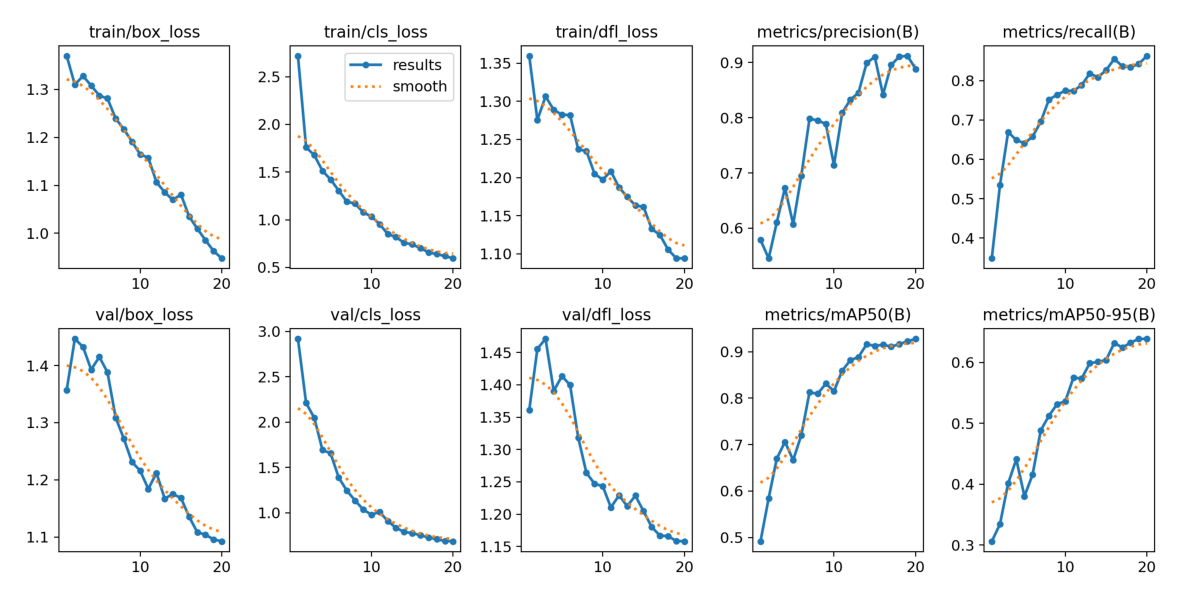

In [8]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("runs/detect/helmet_training/yolov8n_helmet-2/results.png")

plt.figure(figsize=(15,8))
plt.imshow(img)
plt.axis("off")
plt.show()

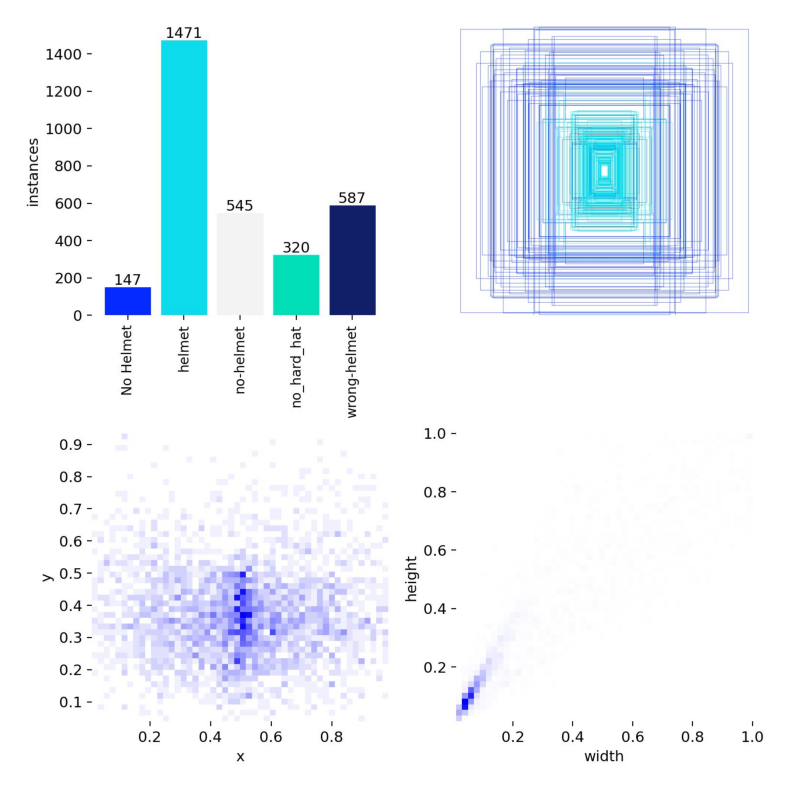

In [9]:
img = Image.open("runs/detect/helmet_training/yolov8n_helmet-2/labels.jpg")

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.show()

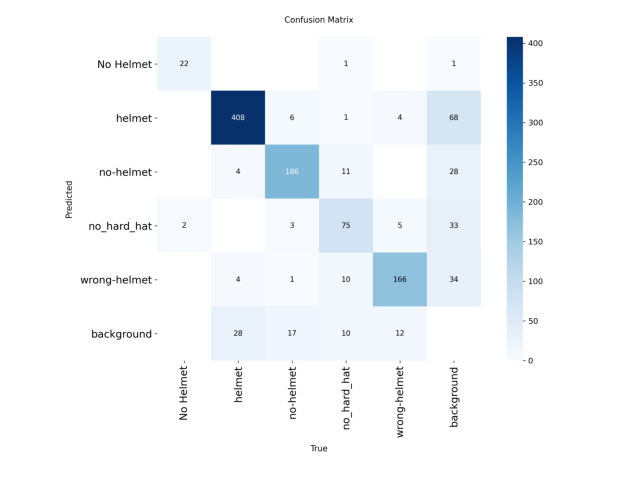

In [10]:
img = Image.open("runs/detect/helmet_training/yolov8n_helmet-2/confusion_matrix.png")

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [11]:
from google.colab import files

files.download(
    "runs/detect/helmet_training/yolov8n_helmet-2/weights/best.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
from google.colab import files

uploaded = files.upload()

Saving images (1).jpg to images (1).jpg


In [13]:
image_name = list(uploaded.keys())[0]

best_model = YOLO(
    "runs/detect/helmet_training/yolov8n_helmet-2/weights/best.pt"
)

results = best_model(image_name)


image 1/1 /content/images (1).jpg: 640x416 3 helmets, 3 no-helmets, 1 wrong-helmet, 150.9ms
Speed: 4.6ms preprocess, 150.9ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 416)


In [14]:
results[0].save(filename="prediction.jpg")

'prediction.jpg'

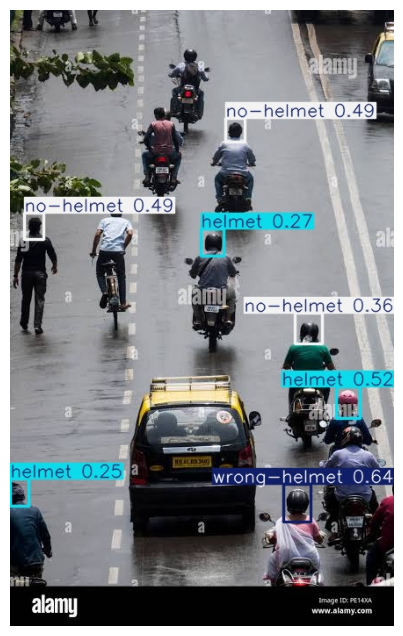

In [15]:
img = Image.open("prediction.jpg")

plt.figure(figsize=(10,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [16]:
for box in results[0].boxes:

    class_id = int(box.cls)
    conf = float(box.conf)

    print(
        best_model.names[class_id],
        f"{conf:.2f}"
    )

wrong-helmet 0.64
helmet 0.52
no-helmet 0.49
no-helmet 0.49
no-helmet 0.36
helmet 0.27
helmet 0.25
